In [2]:
import os

import xarray as xr
import numpy as np

# %matplotlib widget
import matplotlib.pyplot as plt

import sys

%load_ext autoreload
%autoreload 1

sys.path.insert(0, '../../instrument/')
from Agilent.instr_N9928A import N9928A

sys.path.insert(0, '../../pattern/')
%aimport helper_sweep
from helper_sweep import do_sweep

In [3]:
_address = "10.0.100.110"
_instr = N9928A(_address)

Connected to N9928A [10.0.100.110:5025].


In [4]:
_instr.reference('EXT')
_instr.start_frequency(4.8e9)
_instr.stop_frequency(5.5e9)
_instr.if_frequency(1e3)
_instr.average(1, mode='sweep')
_instr.points(1001)
_instr.power(-10)

In [5]:
config_device = [_instr]
config_sweep = [
    [
        [_instr.power, 'power_dbm', np.array([-10])]
    ]
]

In [6]:
# config_sweep = [
#     [
#         [_instr.center_frequency, 'center_frequency_hz', np.array([5.01, 5.02]) * 1e9]
#     ]
# ]

In [7]:
file_path = os.path.join(os.getcwd(), 'boloq_1.zarr')
do_sweep(config_device, config_sweep, _instr.get_trace, file_path)

100%|██████████| 1/1 [00:04<00:00,  4.77s/it]


In [7]:
_instr.reference('EXT')
_instr.start_frequency(4.8e9)
_instr.stop_frequency(5.5e9)
_instr.if_frequency(1e3)
_instr.average(1, mode='sweep')
_instr.points(1001)
_instr.power(-10)

In [ ]:
file_path = os.path.join(os.getcwd(), 'boloq_1.zarr')
do_sweep(config_device, config_sweep, _instr.get_trace, file_path)

In [8]:
file_path = 'boloq_1.zarr'

with xr.open_zarr(file_path, consolidated=False) as f:
    raw_data = f['S21']

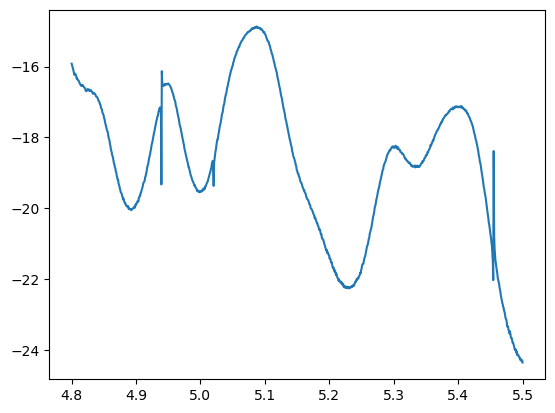

In [9]:
plt.figure()

try:
    plt.pcolormesh(raw_data.N9928A_frequency_hz/1e9, raw_data.N9928A_power_dbm, 20*np.log10(np.abs(raw_data).max(dim='N9928A_if_frequency_hz')).squeeze())
    plt.colorbar()
except:
    plt.plot(raw_data.N9928A_frequency_hz/1e9, 20*np.log10(np.abs(raw_data.squeeze())))

plt.show()